In [1]:
import numpy as np
import cv2 as cv
import glob
import matplotlib.pyplot as plt
import math

# --- Configuração ---
pattern_size = (9, 4)       # cantos internos fixos
square_size_mm = 90.0
IMG_FOLDER = 'img/*.jpg'   # ajuste com *.jpg para listar os arquivos da pasta

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objp = np.zeros((pattern_size[0]*pattern_size[1], 3), np.float32)
objp[:,:2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1,2)
objp *= square_size_mm

objpoints = []
imgpoints = []
img_shape = None
results = []  # (nome, sucesso, imagem_com_desenho)

images = sorted(glob.glob(IMG_FOLDER))
print(f"{len(images)} imagens encontradas\n")

for fname in images:
    img = cv.imread(fname)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_shape = gray.shape[::-1]

    # Detector novo, mais robusto (reflexo, pouca margem, ângulo)
    ret, corners = cv.findChessboardCornersSB(
        gray, pattern_size,
        flags=cv.CALIB_CB_EXHAUSTIVE + cv.CALIB_CB_ACCURACY
    )

    img_draw = img.copy()

    if ret:
        objpoints.append(objp)
        imgpoints.append(corners)
        cv.drawChessboardCorners(img_draw, pattern_size, corners, ret)
        print(f"OK     : {fname}")
    else:
        print(f"FALHOU : {fname}")

    # BGR -> RGB para exibir corretamente com matplotlib
    img_rgb = cv.cvtColor(img_draw, cv.COLOR_BGR2RGB)
    results.append((fname.split('/')[-1], ret, img_rgb))

print(f"\n{len(objpoints)}/{len(images)} imagens aproveitadas")

20 imagens encontradas

OK     : img/20260924_192821.jpg
OK     : img/20260924_192823.jpg
OK     : img/20260924_192824.jpg
OK     : img/20260924_192827.jpg
OK     : img/20260924_192828.jpg
OK     : img/20260924_192829.jpg
OK     : img/20260924_192830.jpg
OK     : img/20260924_192831.jpg
OK     : img/20260924_192833.jpg
OK     : img/20260924_192834.jpg
OK     : img/20260924_192836.jpg
OK     : img/20260924_192839.jpg
OK     : img/20260924_192841.jpg
OK     : img/20260924_192843.jpg
OK     : img/20260924_192845.jpg
OK     : img/20260924_192846.jpg
OK     : img/20260924_192847.jpg
OK     : img/20260924_192848.jpg
OK     : img/20260924_192850.jpg
OK     : img/20260924_192852.jpg

20/20 imagens aproveitadas


/var/folders/px/xrb5zhlx4njgw_ms6_ypx0rw0000gn/T/ipykernel_2744/658951554.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/brunow/Documents/Mestrado/Visão_Computacional/Trabalho_2/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


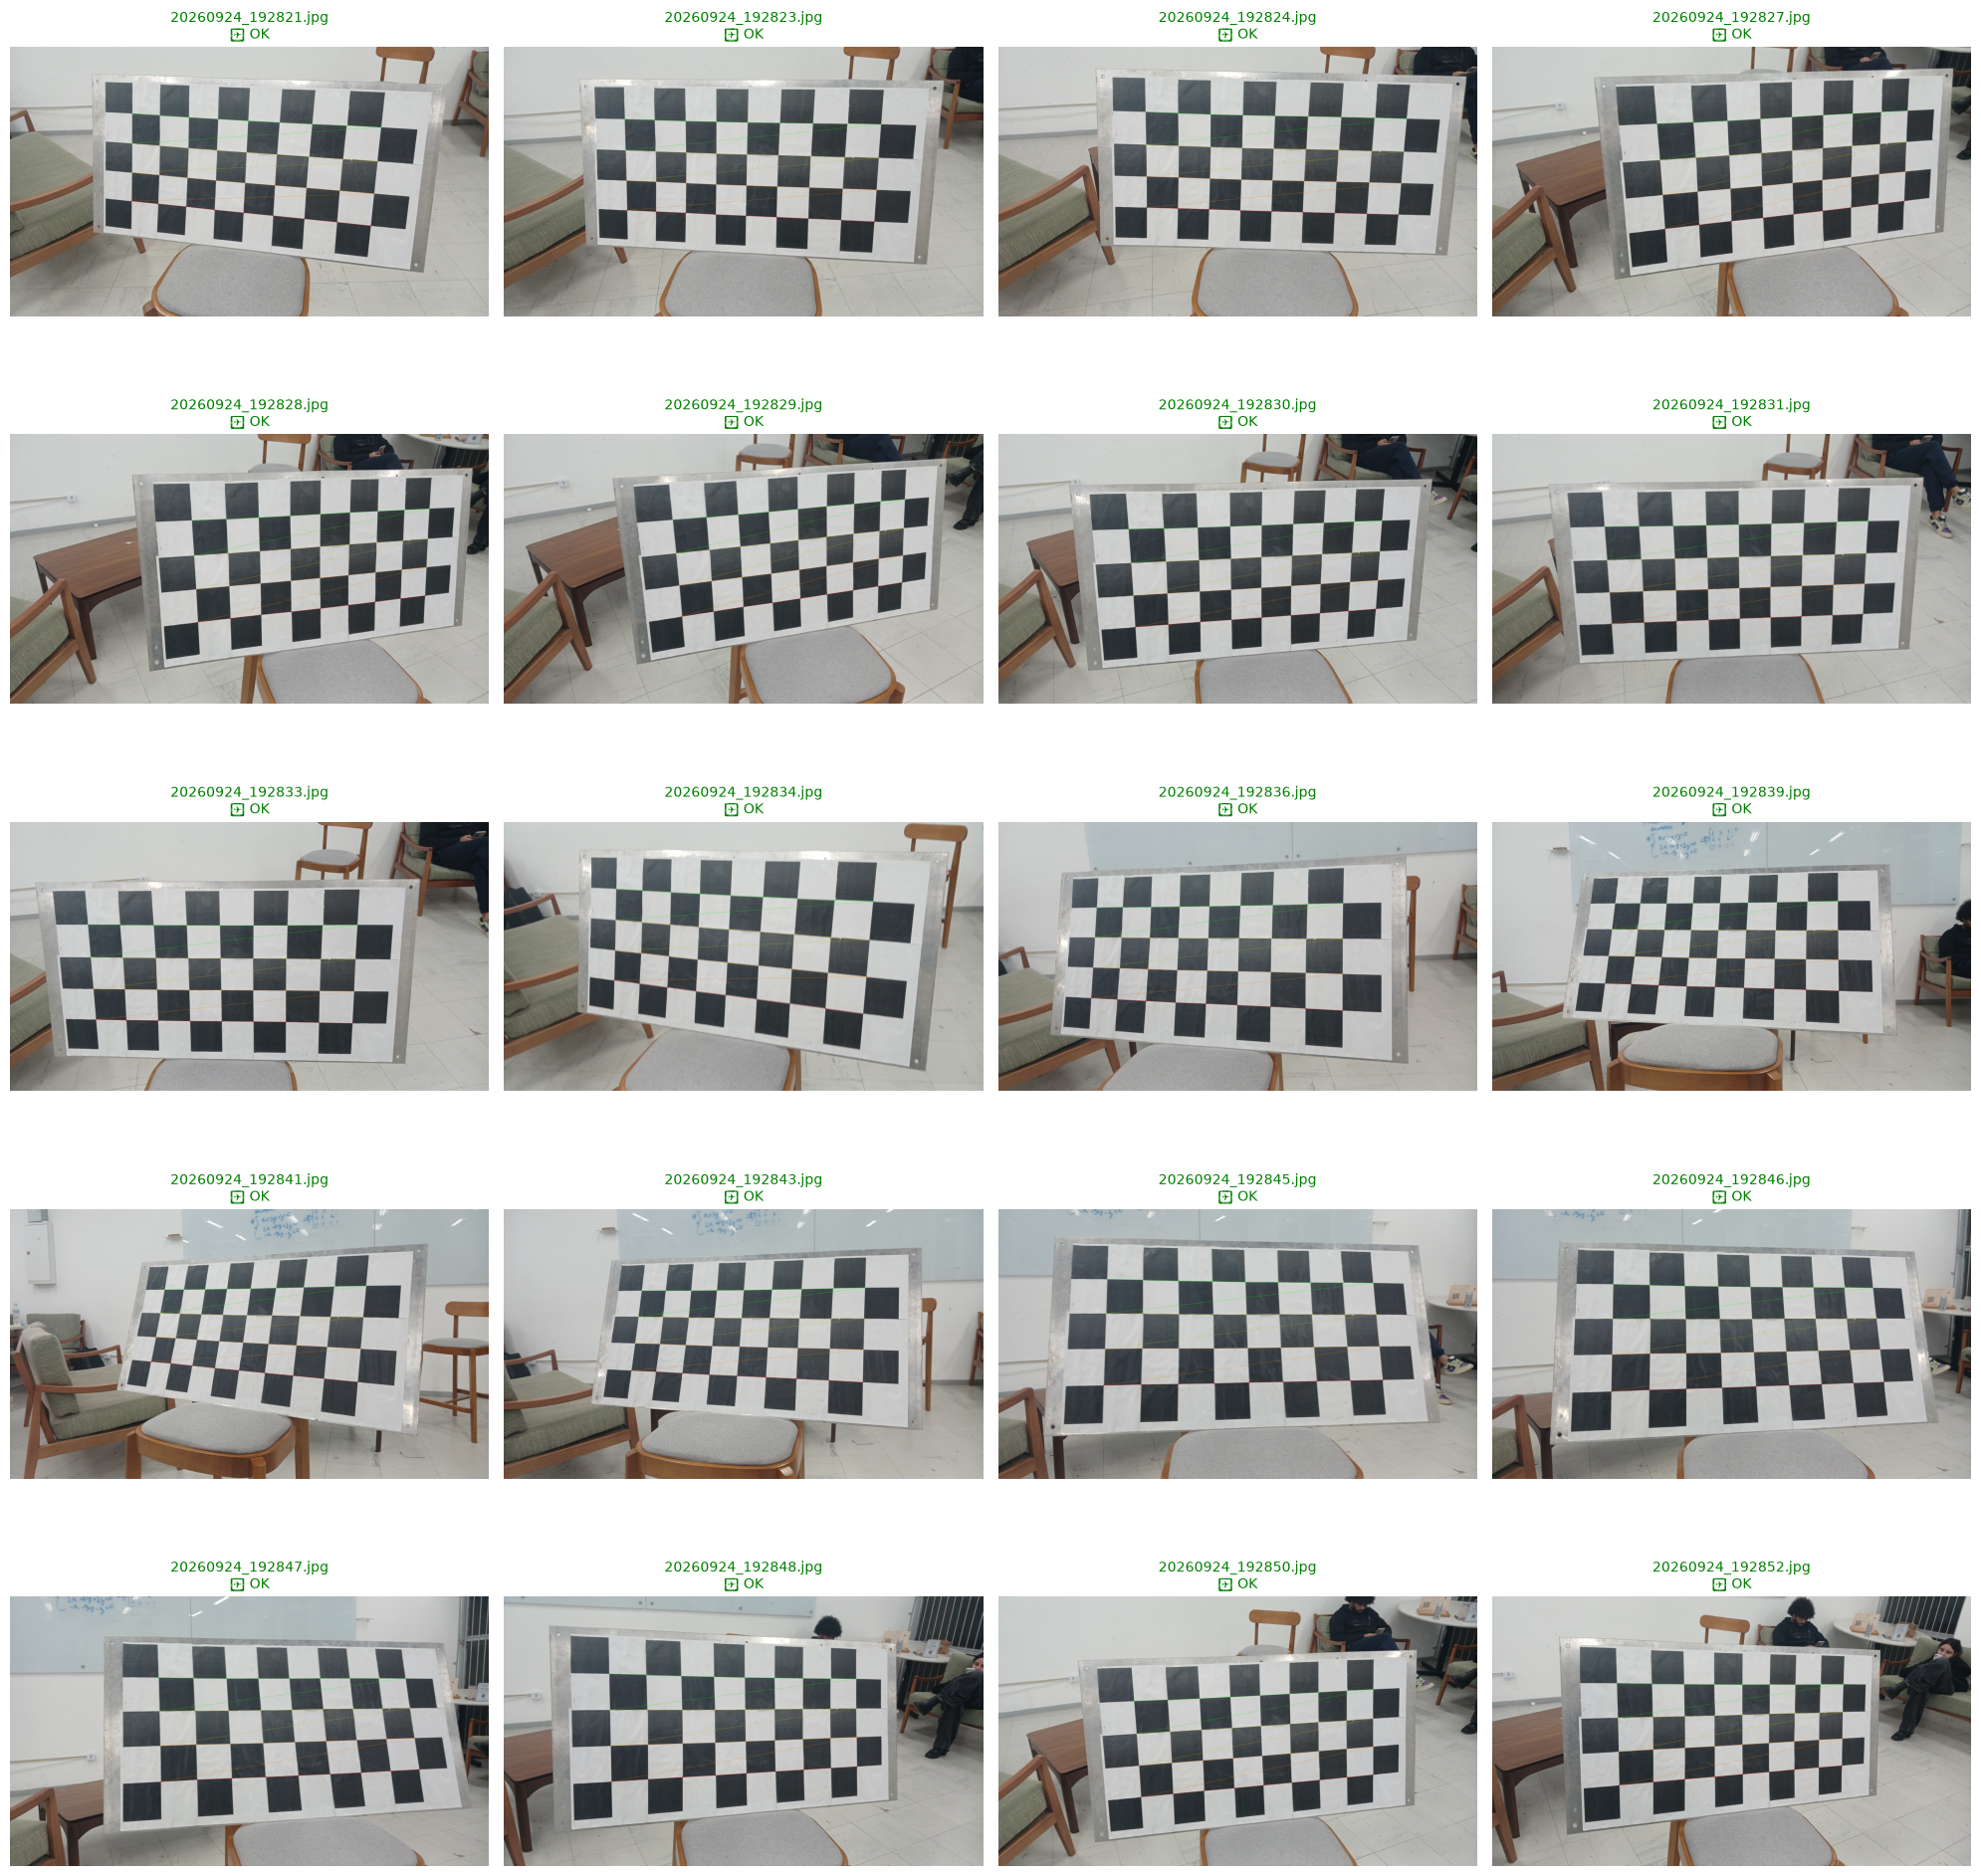

In [2]:
# --- Grid de visualização ---
n = len(results)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for ax, (name, ok, img_rgb) in zip(axes, results):
    ax.imshow(img_rgb)
    ax.set_title(f"{name}\n{'✅ OK' if ok else '❌ FALHOU'}",
                 color='green' if ok else 'red', fontsize=10)
    ax.axis('off')

# apaga eixos sobrando se n não for múltiplo de cols
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

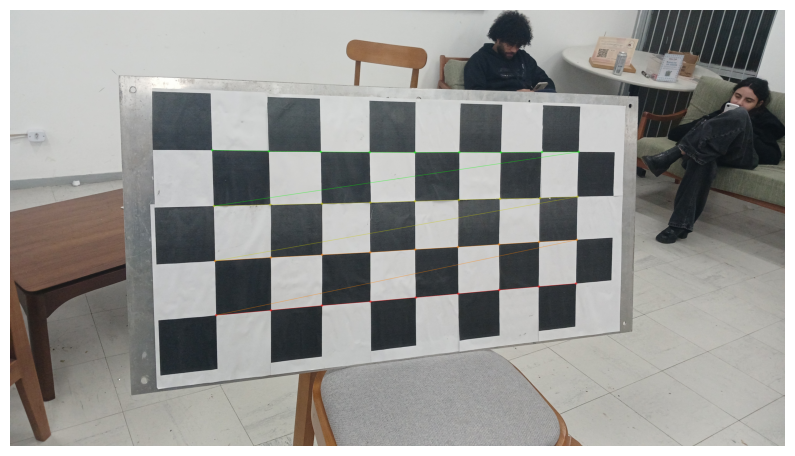

In [3]:
# cv2_imshow é exclusivo do Google Colab; no Jupyter local tem q ser matplotlib:
plt.figure(figsize=(10, 6))
plt.imshow(results[-1][2])
plt.axis('off')
plt.show()

Erro RMS de reprojeção: 2.6627 pixels (quanto mais próximo de 0, melhor)


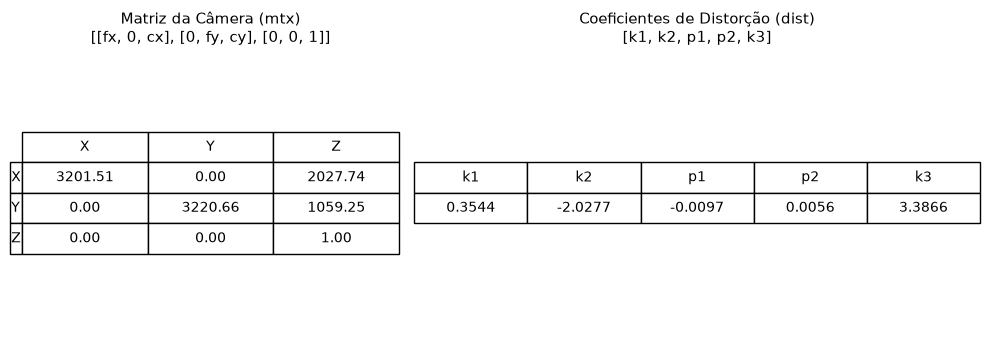

In [4]:
# --- Calibração da Câmera ---
ret_val, mtx, dist, rvecs, tvecs = cv.calibrateCamera(
    objpoints, imgpoints, img_shape, None, None
)

print(f"Erro RMS de reprojeção: {ret_val:.4f} pixels (quanto mais próximo de 0, melhor)")

# Plot visual da Matriz da Câmera (3x3) e Coeficientes de Distorção (1x5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={'width_ratios': [1.2, 1.8]})

# 1. Tabela da Matriz Intrínseca (mtx)
ax1.axis('off')
ax1.set_title("Matriz da Câmera (mtx)\n[[fx, 0, cx], [0, fy, cy], [0, 0, 1]]", fontsize=11, pad=10)
cell_text_mtx = [[f"{val:.2f}" for val in row] for row in mtx]
table_mtx = ax1.table(cellText=cell_text_mtx, loc='center', cellLoc='center',
                      rowLabels=['X', 'Y', 'Z'], colLabels=['X', 'Y', 'Z'])
table_mtx.scale(1, 1.8)

# 2. Tabela dos Coeficientes de Distorção (dist)
ax2.axis('off')
ax2.set_title("Coeficientes de Distorção (dist)\n[k1, k2, p1, p2, k3]", fontsize=11, pad=10)
cell_text_dist = [[f"{val:.4f}" for val in dist.ravel()]]
table_dist = ax2.table(cellText=cell_text_dist, loc='center', cellLoc='center',
                       colLabels=['k1', 'k2', 'p1', 'p2', 'k3'])
table_dist.scale(1, 1.8)

plt.tight_layout()
plt.show()

Resolução da imagem: 4080x2296 px
Diferença máxima de intensidade: 213 (escala 0-255)
Diferença média por pixel: 16.33
Deslocamento máximo nos cantos da imagem: 66.4 pixels


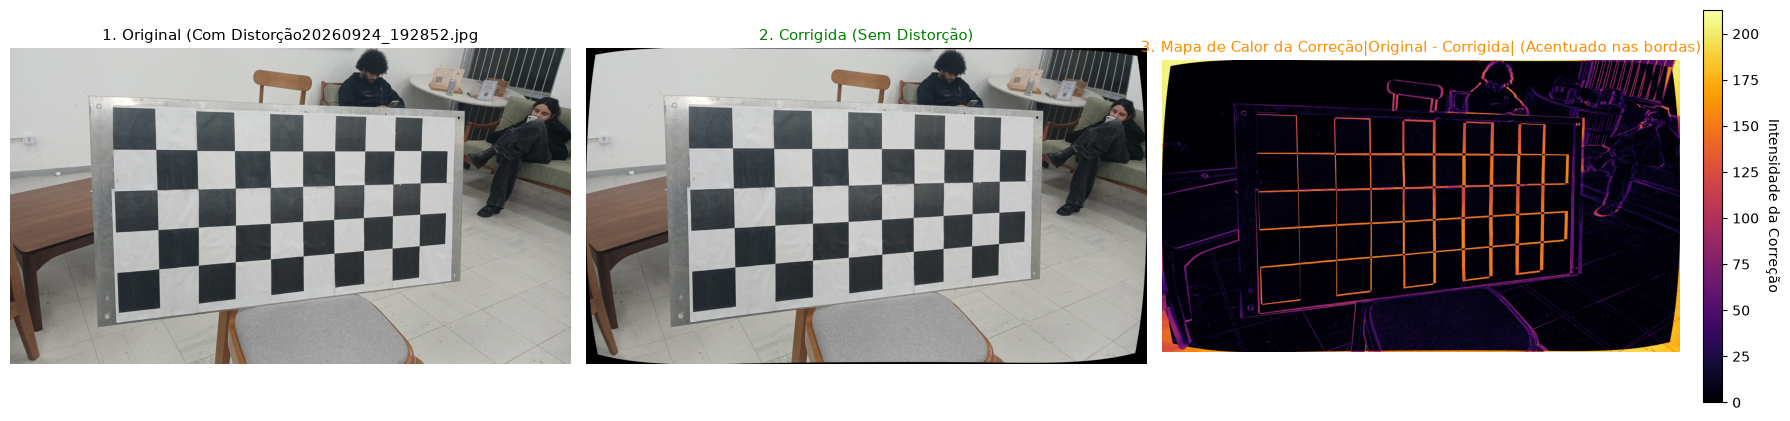

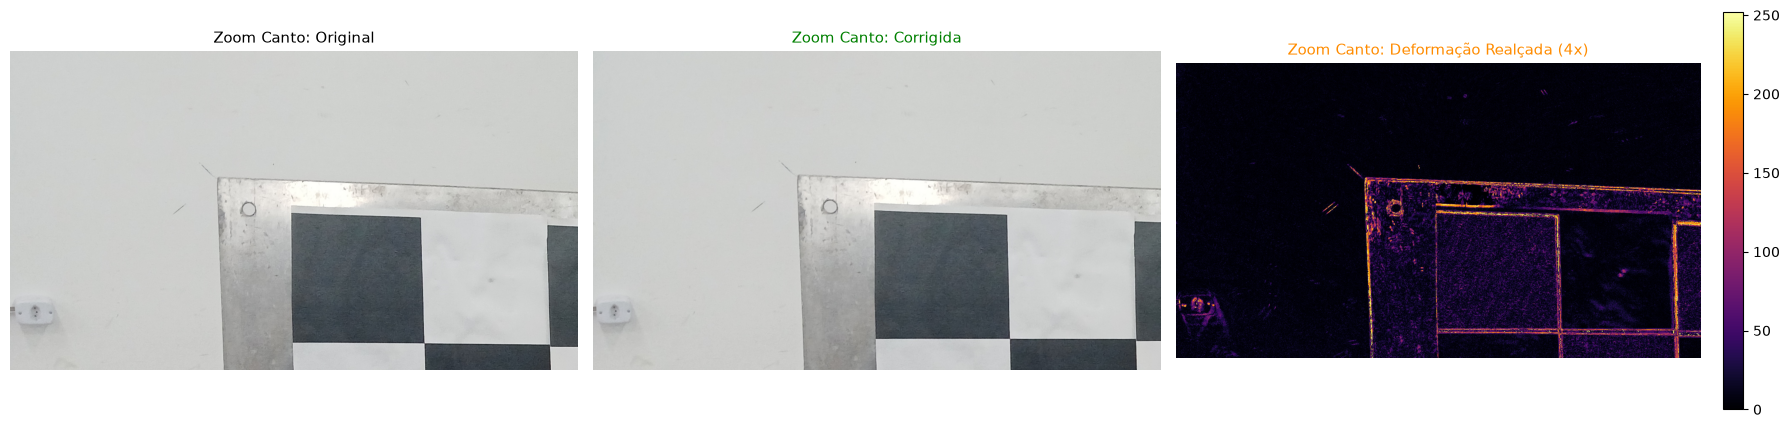

In [5]:
# --- Remoção de Distorção, Comparação e Mapa de Calor ---
# Pega a última imagem processada para o teste
test_img_path = images[-1]
img_original_bgr = cv.imread(test_img_path)
h, w = img_original_bgr.shape[:2]

# Otimiza a matriz intrínseca para manter o enquadramento adequado
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))

# Remove a distorção da imagem
img_undistorted_bgr = cv.undistort(img_original_bgr, mtx, dist, None, newcameramtx)

# Converte para RGB para exibição correta no matplotlib
img_orig_rgb = cv.cvtColor(img_original_bgr, cv.COLOR_BGR2RGB)
img_undist_rgb = cv.cvtColor(img_undistorted_bgr, cv.COLOR_BGR2RGB)

# 1. Cálculo da Diferença Absoluta entre Original e Corrigida
diff = cv.absdiff(img_orig_rgb, img_undist_rgb)
diff_gray = cv.cvtColor(diff, cv.COLOR_RGB2GRAY)

# Deslocamento teórico estimado nos 4 cantos
corner_pts = np.array([[[100, 100]], [[w-100, 100]], [[100, h-100]], [[w-100, h-100]]], dtype=np.float32)
undist_corner_pts = cv.undistortPoints(corner_pts, mtx, dist, P=newcameramtx)
corner_displacements = [np.linalg.norm(c1[0] - c2[0]) for c1, c2 in zip(corner_pts, undist_corner_pts)]
max_corner_disp = max(corner_displacements)

print(f"Resolução da imagem: {w}x{h} px")
print(f"Diferença máxima de intensidade: {diff_gray.max()} (escala 0-255)")
print(f"Diferença média por pixel: {diff_gray.mean():.2f}")
print(f"Deslocamento máximo nos cantos da imagem: {max_corner_disp:.1f} pixels")

# 2. Visualização Completa: Original, Corrigida e Mapa de Calor (Heatmap)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_orig_rgb)
axes[0].set_title(f"1. Original (Com Distorção{test_img_path.split('/')[-1]}", fontsize=11)
axes[0].axis('off')

axes[1].imshow(img_undist_rgb)
axes[1].set_title("2. Corrigida (Sem Distorção)", fontsize=11, color='green')
axes[1].axis('off')

im3 = axes[2].imshow(diff_gray, cmap='inferno')
axes[2].set_title("3. Mapa de Calor da Correção|Original - Corrigida| (Acentuado nas bordas)", fontsize=11, color='darkorange')
axes[2].axis('off')
cbar = fig.colorbar(im3, ax=axes[2], fraction=0.035, pad=0.04)
cbar.set_label('Intensidade da Correção', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# 3. Zoom detalhado no canto superior esquerdo (onde a distorção atua fortemente)
crop_y1, crop_y2 = int(h * 0.02), int(h * 0.35)
crop_x1, crop_x2 = int(w * 0.02), int(w * 0.35)

fig_zoom, axes_z = plt.subplots(1, 3, figsize=(18, 5))

axes_z[0].imshow(img_orig_rgb[crop_y1:crop_y2, crop_x1:crop_x2])
axes_z[0].set_title("Zoom Canto: Original", fontsize=11)
axes_z[0].axis('off')

axes_z[1].imshow(img_undist_rgb[crop_y1:crop_y2, crop_x1:crop_x2])
axes_z[1].set_title("Zoom Canto: Corrigida", fontsize=11, color='green')
axes_z[1].axis('off')

im_z_diff = axes_z[2].imshow(diff_gray[crop_y1:crop_y2, crop_x1:crop_x2] * 4, cmap='inferno')
axes_z[2].set_title("Zoom Canto: Deformação Realçada (4x)", fontsize=11, color='darkorange')
axes_z[2].axis('off')
fig_zoom.colorbar(im_z_diff, ax=axes_z[2], fraction=0.035, pad=0.04)

plt.tight_layout()
plt.show()